# Gene regulatory network analysis (SCENIC + morphogen GRNBoost2)

Python recreation of the GRN analysis described in `grn_analysis_description.txt`, applied to the
NGN2 / iGlut_post dataset **`ngn2_scrna_processed.h5ad`**.

**Pipeline**
1. Run SCENIC (GRNBoost2 + cisTarget motif pruning) `N_RUNS` times, each on a subsample of
   `CELLS_PER_CLUSTER` cells per cluster (with replacement, new random seed each run).
2. Build **consensus regulons**: keep TF->target interactions seen in ≥ `CONSENSUS_MIN_RUNS` runs.
3. Score every cell with **AUCell** using the consensus regulons.
4. Run **GRNBoost2** again to link morphogen concentrations / basal media (plus hardcoded pairwise
   `a:b` and triple `a:b:c` interaction terms) to regulon activity.
5. **Strongest-link cleanup**: if an individual variable's link to a regulon is weaker than an
   interaction term containing it, keep only the strongest link.
6. Filter links with `w > WEIGHT_FILTER` (**200**, matching the published Fig 3E — the paper's
   plotting code filtered at 200 even though the methods text states 250).
7. Plot the morphogen→regulon **network** (Python/networkx port of the original R `ggraph` figure).

### How to run
This notebook needs pySCENIC and must run inside the singularity container. Launch Jupyter from the
container, e.g.

```bash
SIF=/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/aertslab-pyscenic-scanpy-0.12.1-1.9.1.sif
singularity exec -B /shared:/shared $SIF jupyter nbconvert --to notebook --execute grn_analysis.ipynb
```

Every parameter in the config cell can be overridden with `GRN_*` environment variables, so the same
notebook can be smoke-tested small or run in full.

> **Runtime note:** the full run (20 SCENIC iterations + AUCell over ~188k cells + 3 morphogen seeds)
> takes several hours. Each step checkpoints to `OUTDIR`, so you can run steps one at a time and the
> figure can be regenerated without recomputing SCENIC.

> **Pre-computed mode:** `step_consensus`, `step_aucell` and `step_morphogens` load their existing outputs from `OUTDIR` (`consensus_regulons.p`, `auc_mtx.p`, `module_summary.tsv`) instead of recomputing when those files are present. Set the environment variable `GRN_USE_PRECOMPUTED=0` to force a full recompute.

## 0. Configuration & imports

Every tunable parameter lives in the single config cell below, and each one can be overridden from the
environment with a matching `GRN_*` variable — so the same notebook runs as a quick demo or as a full
production job without editing any code. The knobs that most affect the result:

- **`N_RUNS`** — how many independent SCENIC iterations feed the consensus (demo default `3`; the paper
  used `20`). More runs ⇒ more reproducible regulons survive the consensus ⇒ a denser final network.
- **`CELLS_PER_CLUSTER` / `CLUSTER_KEY`** — each SCENIC run works on a balanced subsample of
  `CELLS_PER_CLUSTER` cells drawn per `cell_type` cluster, so rare clusters are not drowned out.
- **`CONSENSUS_MIN_RUNS`** — a TF→target edge must reappear in at least this many runs to be kept.
- **`MORPH_SEEDS` / `MORPH_MIN_SEEDS`** — the random seeds for the morphogen GRNBoost2 step and how many
  of them must agree before a morphogen→regulon link is kept.
- **`WEIGHT_FILTER`** — final edge-weight cutoff for the figure (`200`, matching Fig 3E).
- **`USE_PRECOMPUTED`** — when `True` (default), the three expensive steps (`step_consensus`,
  `step_aucell`, `step_morphogens`) load their cached output from `OUTDIR` instead of recomputing.
  Set `GRN_USE_PRECOMPUTED=0` to force a full recompute.

The config also defines the morphogen/media variables and the brain-region colour palette used for the
network figure.

In [10]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import glob
import pickle
import re
import sys
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import scanpy as sc

warnings.simplefilter(action="ignore", category=FutureWarning)

# --------------------------------------------------------------------------- #
# 0. Configuration (override with GRN_* environment variables)
# --------------------------------------------------------------------------- #
BASE       = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared"
# Container-compatible slim copy (anndata 0.8 in the pySCENIC image cannot read the
# nullable-string encodings in the original ngn2_scrna_processed.h5ad). Build it once with
# make_slim.py; it keeps X (log-normalised), the cluster/morphogen/region obs columns and var.
DATA_PATH  = os.environ.get("GRN_DATA",   f"{BASE}/ngn2_scrna_processed_scenic.h5ad")
RES_DIR    = os.environ.get("GRN_RES",    f"{BASE}/cistarget")
OUTDIR     = os.environ.get("GRN_OUTDIR", f"{BASE}/pyscenic_run")

DATABASES_GLOB          = os.path.join(RES_DIR, "*.genes_vs_motifs.rankings.feather")
MOTIF_ANNOTATIONS_FNAME = os.path.join(RES_DIR, "motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl")
HG_TFS_FNAME            = os.path.join(RES_DIR, "allTFs_hg38.txt")

# SCENIC subsampling / consensus
N_RUNS             = int(os.environ.get("GRN_N_RUNS", 20))
CELLS_PER_CLUSTER  = int(os.environ.get("GRN_CELLS_PER_CLUSTER", 100))
CLUSTER_KEY        = os.environ.get("GRN_CLUSTER_KEY", "cell_type")   # ~ "final_clustering"
CONSENSUS_MIN_RUNS = int(os.environ.get("GRN_CONSENSUS_MIN_RUNS", 5))

# Morphogen -> regulon GRNBoost2
MORPH_SEEDS     = [int(x) for x in os.environ.get("GRN_MORPH_SEEDS", "42,25,7").split(",")]
MORPH_MIN_SEEDS = int(os.environ.get("GRN_MORPH_MIN_SEEDS", 2))   # consensus across seeds
WEIGHT_FILTER   = float(os.environ.get("GRN_WEIGHT_FILTER", 200))  # published Fig 3E used 200
                                                                   # (the methods text says 250)

# Compute / IO
N_WORKERS      = int(os.environ.get("GRN_N_WORKERS", 12))
GENE_MIN_CELLS = int(os.environ.get("GRN_GENE_MIN_CELLS", 3))     # drop ~all-zero genes
REGION_KEY     = os.environ.get("GRN_REGION_KEY", "Region")

AUCELL_MAX_CELLS = int(os.environ.get("GRN_AUCELL_MAX_CELLS", 0))  # 0 = all cells
SUBSET_N_CELLS   = int(os.environ.get("GRN_SUBSET_N_CELLS", 0))    # 0 = all cells (smoke test knob)

# Load pre-computed step outputs (consensus regulons / AUCell matrix / morphogen
# module summary) from OUTDIR instead of recomputing them, when those files exist.
# Set GRN_USE_PRECOMPUTED=False to force a full recompute.
USE_PRECOMPUTED = True

os.makedirs(OUTDIR, exist_ok=True)

MORPHOGENS     = ["XAV", "CHIR", "RA", "FGF8", "BMP4", "SHH", "PM", "CycA"]
MORPHOGEN_VARS = ["M_" + x for x in MORPHOGENS] + ["N2B27_2Si", "NIM", "N2B27_SB_CHIR"]

# Brain-region palette (paper Fig 3E panel E), used to colour regulon nodes.
REGION_PALETTE = {
    "Forebrain": "#fe9b00", "Midbrain": "#f4c40f", "Hindbrain": "#d8443c",
    "Spinal cord": "#9b3441", "SYM": "#268a8a", "ENS": "#3b7dd8",
    "TG": "#633372", "DRG": "#4ba56b",
}


# --------------------------------------------------------------------------- #


## Helper functions

Two small utilities used throughout the pipeline:

- **`load_adata`** reads the (container-friendly, log-normalised) dataset and prepares `obs`:
  it stores the cell barcode as an explicit `CellID` column (needed later to align subsamples and the
  AUCell matrix back to the full table), adds the one-hot **basal-media indicator** columns
  (`N2B27_2Si`, `NIM`, `N2B27_SB_CHIR`) and the `M_CycA` morphogen column, and drops all-but-empty
  genes. An optional `SUBSET_N_CELLS` knob subsamples cells for a fast smoke test.
- **`dense_df`** turns an AnnData's `X` into a plain cells×genes `DataFrame` of the log-normalised
  expression. GRNBoost2 wants a dense frame; this is only ever called on a *subsample*, so the dense
  copy stays small.

In [11]:
def log(*a):
    print(*a, flush=True)


def load_adata():
    """Load the dataset, add morphogen/media indicator columns, light gene filter."""
    log(f"Reading {DATA_PATH} ...")
    adata = sc.read_h5ad(DATA_PATH)
    adata.obs["CellID"] = adata.obs.index

    if SUBSET_N_CELLS and SUBSET_N_CELLS < adata.n_obs:
        rng = np.random.RandomState(0)
        idx = np.sort(rng.choice(adata.n_obs, SUBSET_N_CELLS, replace=False))
        adata = adata[idx].copy()
        log(f"  [smoke] subset to {adata.n_obs} cells")

    if GENE_MIN_CELLS > 0:
        sc.pp.filter_genes(adata, min_cells=GENE_MIN_CELLS)
    log(f"  adata: {adata.n_obs} cells x {adata.n_vars} genes")

    # Basal-media indicators (constant in this dataset, kept for fidelity)
    for m in ["N2B27_2Si", "NIM", "N2B27_SB_CHIR"]:
        adata.obs[m] = 0
    if "Basal_media" in adata.obs.columns:
        for m in ["N2B27_2Si", "NIM", "N2B27_SB_CHIR"]:
            adata.obs.loc[adata.obs["Basal_media"] == m, m] = 1
    if "CycA" in adata.obs.columns:
        adata.obs["M_CycA"] = adata.obs["CycA"]
    return adata


def dense_df(adata_subset):
    """cells x genes dense DataFrame (log-normalised X, as in the original)."""
    X = adata_subset.X
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    return pd.DataFrame(X, index=adata_subset.obs.index, columns=adata_subset.var_names)


# --------------------------------------------------------------------------- #


## 1. SCENIC iterations

SCENIC infers **regulons** — a transcription factor together with the target genes it directly
regulates. Each iteration:

1. **Subsamples** `CELLS_PER_CLUSTER` cells per cluster (with replacement) so every cell type is
   represented roughly equally.
2. Runs **GRNBoost2**, a gradient-boosting regression that scores, for every gene, which TFs best
   predict its expression — producing a weighted TF→target adjacency list.
3. Groups those adjacencies into co-expression **modules** and **prunes** them with the cisTarget motif
   databases, keeping only targets that carry the TF's binding motif (this is what makes a regulon a
   *direct*-regulation call rather than mere co-expression).

Because GRNBoost2 is stochastic and the subsample changes each run, we repeat the whole thing `N_RUNS`
times with different seeds and later keep only the reproducible edges (step 2). Each run is independent
and idempotent — its regulons are pickled and skipped if already present — so the runs can be spread
across SLURM array tasks (see `run_scenic_array.slurm`).

In [12]:
def load_scenic_resources():
    """Load the TF list and cisTarget ranking databases (shared by every run)."""
    from arboreto.utils import load_tf_names
    from ctxcore.rnkdb import FeatherRankingDatabase as RankingDatabase
    tf_names_all = load_tf_names(HG_TFS_FNAME)
    db_fnames = glob.glob(DATABASES_GLOB)
    dbs = [RankingDatabase(fname=f, name=os.path.splitext(os.path.basename(f))[0]) for f in db_fnames]
    log("Ranking databases:", [d.name for d in dbs])
    return tf_names_all, dbs


def run_single_scenic(i, adata, tf_names_all, dbs):
    """Run ONE SCENIC iteration (seed=i) and pickle regulons_<i>.p. Idempotent.

    Each run is independent, so the 20 iterations can be parallelised across
    separate processes / SLURM array tasks (see scenic_iteration.py)."""
    from arboreto.algo import grnboost2
    from pyscenic.utils import modules_from_adjacencies
    from pyscenic.prune import prune2df, df2regulons
    from distributed import LocalCluster, Client

    reg_dir = os.path.join(OUTDIR, "scenic_runs")
    os.makedirs(reg_dir, exist_ok=True)
    out_reg = os.path.join(reg_dir, f"regulons_{i}.p")
    if os.path.exists(out_reg):
        log(f"[run {i}] cached, skipping")
        return

    meta = adata.obs
    log(f"[run {i}] subsampling {CELLS_PER_CLUSTER} cells / '{CLUSTER_KEY}' cluster")
    # Sample per cluster WITH replacement so small clusters can still yield CELLS_PER_CLUSTER draws;
    # set() then collapses any repeated barcodes so each cell enters the subsample at most once.
    sub = list(meta.groupby(CLUSTER_KEY, observed=True)
                   .sample(n=CELLS_PER_CLUSTER, replace=True, random_state=i).index)
    sub = list(set(sub))
    adata_sub = adata[adata.obs["CellID"].isin(sub)].copy()
    dgem = dense_df(adata_sub)
    tf_names = [x for x in tf_names_all if x in dgem.columns]

    cluster = LocalCluster(n_workers=N_WORKERS, threads_per_worker=1, memory_limit="8GB")
    client = Client(cluster)
    try:
        adjacencies = grnboost2(expression_data=dgem, tf_names=tf_names,
                                client_or_address=client, seed=i, verbose=True)
    finally:
        client.close(); cluster.close()

    with open(os.path.join(reg_dir, f"adjacencies_{i}.p"), "wb") as f:
        pickle.dump(adjacencies, f)

    modules = list(modules_from_adjacencies(adjacencies, dgem))
    log(f"[run {i}] pruning {len(modules)} modules with cisTarget ...")
    df = prune2df(dbs, modules, MOTIF_ANNOTATIONS_FNAME, num_workers=N_WORKERS)
    regulons = df2regulons(df)
    with open(out_reg, "wb") as f:
        pickle.dump(regulons, f)
    log(f"[run {i}] -> {len(regulons)} regulons")


def step_scenic(adata):
    """Run all N_RUNS SCENIC iterations serially (use the SLURM array to parallelise)."""
    tf_names_all, dbs = load_scenic_resources()
    for i in range(1, N_RUNS + 1):
        run_single_scenic(i, adata, tf_names_all, dbs)


# --------------------------------------------------------------------------- #


## 2. Consensus regulons

A single SCENIC run is noisy, so we combine the `N_RUNS` runs into one robust set of **consensus
regulons**. For every TF we count, across runs, how often each target gene appears and keep only
targets seen in **≥ `CONSENSUS_MIN_RUNS`** runs; the kept target's weight is the mean of its per-run
weights. The result is one `Regulon` object per TF, pickled to `consensus_regulons.p`.

This is a key robustness filter: with only 3 runs relatively few TFs clear the bar (~70 regulons here),
whereas the paper's 20 runs let many more reproducible regulons through — one of the main reasons the
demo network is sparser than the published one.

In [13]:
def step_consensus():
    from ctxcore.genesig import Regulon
    out_p = os.path.join(OUTDIR, "consensus_regulons.p")
    if USE_PRECOMPUTED and os.path.exists(out_p):
        with open(out_p, "rb") as f:
            consensus = pickle.load(f)
        log(f"[precomputed] loaded {len(consensus)} consensus regulons from {out_p}")
        return consensus

    reg_dir = os.path.join(OUTDIR, "scenic_runs")
    files = sorted(glob.glob(os.path.join(reg_dir, "regulons_*.p")))
    if not files:
        raise RuntimeError("No SCENIC runs found; run step 'scenic' first.")
    log(f"Building consensus from {len(files)} runs (min_runs={CONSENSUS_MIN_RUNS})")

    counts  = defaultdict(lambda: defaultdict(int))    # tf -> gene -> #runs
    weights = defaultdict(lambda: defaultdict(list))   # tf -> gene -> [weights]
    for fn in files:
        with open(fn, "rb") as f:
            regulons = pickle.load(f)
        seen = defaultdict(set)   # a TF may span several motif-regulons in one run; count gene once/run
        for reg in regulons:
            tf = reg.transcription_factor
            for gene, w in reg.gene2weight.items():
                weights[tf][gene].append(float(w))
                seen[tf].add(gene)
        for tf, genes in seen.items():
            for gene in genes:
                counts[tf][gene] += 1

    consensus = []
    for tf, gene_counts in counts.items():
        g2w = {g: float(np.mean(weights[tf][g])) for g, c in gene_counts.items()
               if c >= CONSENSUS_MIN_RUNS}
        if not g2w:
            continue
        consensus.append(Regulon(
            name=f"{tf}(+)", gene2weight=g2w, gene2occurrence={},
            transcription_factor=tf, context=frozenset(["consensus"]), score=0.0))
    med = int(np.median([len(r.genes) for r in consensus])) if consensus else 0
    log(f"Consensus: {len(consensus)} regulons (median size {med})")
    with open(os.path.join(OUTDIR, "consensus_regulons.p"), "wb") as f:
        pickle.dump(consensus, f)
    return consensus


# --------------------------------------------------------------------------- #


## 3. AUCell

**AUCell** turns the qualitative regulons into a quantitative, per-cell activity score. For each cell it
ranks all genes by expression and asks, for each regulon, how enriched that regulon's targets are near
the top of the ranking (the area under the recovery curve). The output is a cells × regulons matrix of
**regulon activities**, saved to `auc_mtx.p`. This matrix is what the morphogen step (below) treats as
the "expression" of each regulon, and what the figure uses to assign each regulon its dominant brain
region.

In [14]:
def step_aucell(adata):
    from pyscenic.aucell import aucell
    out_p = os.path.join(OUTDIR, "auc_mtx.p")
    if USE_PRECOMPUTED and os.path.exists(out_p):
        auc_mtx = pd.read_pickle(out_p)
        log(f"[precomputed] loaded AUCell matrix {auc_mtx.shape} from {out_p}")
        return auc_mtx

    with open(os.path.join(OUTDIR, "consensus_regulons.p"), "rb") as f:
        regulons = pickle.load(f)

    a = adata
    if AUCELL_MAX_CELLS and AUCELL_MAX_CELLS < adata.n_obs:
        rng = np.random.RandomState(0)
        idx = np.sort(rng.choice(adata.n_obs, AUCELL_MAX_CELLS, replace=False))
        a = adata[idx].copy()
    log(f"AUCell on {a.n_obs} cells x {len(regulons)} regulons ...")

    # AUCell needs a genes-per-cell DataFrame. X is usually a sparse matrix over ~188k cells, which
    # would be huge if densified, so wrap it in a sparse-backed DataFrame; fall back to dense only if
    # that is not possible (e.g. X already dense).
    X = a.X
    try:
        dgem = pd.DataFrame.sparse.from_spmatrix(X, index=a.obs.index, columns=a.var_names)
    except Exception:
        X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
        dgem = pd.DataFrame(X, index=a.obs.index, columns=a.var_names)

    auc_mtx = aucell(dgem, regulons, num_workers=N_WORKERS)
    auc_mtx.to_pickle(os.path.join(OUTDIR, "auc_mtx.p"))
    log(f"AUCell matrix: {auc_mtx.shape}")
    return auc_mtx


# --------------------------------------------------------------------------- #


## 4. Morphogen → regulon GRNBoost2

Now we ask *which morphogens/media drive which regulons*. We take the AUCell activity matrix and append,
as extra columns, the morphogen/media indicator variables **plus every pairwise (`a:b`) and triple
(`a:b:c`) interaction product** of them. We then run GRNBoost2 again, but this time telling it to use
only those morphogen/interaction columns as regulators — so it links morphogen conditions to regulon
activity. The interaction products let the model attribute a regulon to a specific *combination* of
morphogens (e.g. `RA:SHH`) rather than forcing it onto single morphogens.

This is repeated over `MORPH_SEEDS`, and we keep the links seen in **≥ `MORPH_MIN_SEEDS`** seeds, using
the mean weight — the per-seed and consensus tables are written to `OUTDIR`. Note the interaction terms
are only a modelling device here; they are collapsed back onto individual morphogens in step 5 and never
appear as nodes in the figure.

In [15]:
def add_interaction_terms(meta, variables):
    """All pairwise (a:b) and triple (a:b:c) products of morphogen variables."""
    # Each product is 1 only when ALL of its component morphogens are present in a cell, so an
    # interaction column marks the cells exposed to that specific combination. Build every column first
    # and concat once (assigning them one-by-one into `meta` would fragment the frame and be slow).
    new = {}
    for m1 in variables:
        for m2 in variables:
            if m1 == m2:
                continue
            new[f"{m1}:{m2}"] = meta[m1] * meta[m2]
            for m3 in variables:
                if m3 not in (m1, m2):
                    new[f"{m1}:{m2}:{m3}"] = meta[m1] * meta[m2] * meta[m3]
    return pd.concat([meta, pd.DataFrame(new, index=meta.index)], axis=1)


def get_variable_columns(meta, keep_cols):
    """Keep only variable (non-constant, sum>0), de-duplicated columns."""
    mv = meta[keep_cols].copy()
    s = mv.sum()
    mv = mv[s[s > 0].index]                 # drop all-zero (never-present) variables
    # Transpose-dedup: two variables that happen to be identical across all cells (e.g. two morphogens
    # always given together, so their interaction equals each individual column) would confuse GRNBoost2
    # with perfectly collinear regressors — keep only one representative.
    return mv.T.drop_duplicates().T


def step_morphogens(adata):
    from arboreto.algo import grnboost2
    from pyscenic.utils import modules_from_adjacencies
    from distributed import LocalCluster, Client

    out_tsv = os.path.join(OUTDIR, "module_summary.tsv")
    if USE_PRECOMPUTED and os.path.exists(out_tsv):
        grp = pd.read_csv(out_tsv, sep="\t")
        log(f"[precomputed] loaded {grp.shape[0]} morphogen->regulon links from {out_tsv}")
        return grp

    auc_mtx = pd.read_pickle(os.path.join(OUTDIR, "auc_mtx.p"))
    meta = adata.obs.loc[auc_mtx.index].copy()

    present = [v for v in MORPHOGEN_VARS if v in meta.columns]
    meta = add_interaction_terms(meta, present)
    all_terms = present + [c for c in meta.columns if ":" in c]
    meta_var = get_variable_columns(meta, all_terms)
    log(f"Morphogen/media/interaction variables kept ({meta_var.shape[1]}): {list(meta_var.columns)[:12]} ...")

    mat = auc_mtx.copy()
    for c in meta_var.columns:
        mat[c] = meta_var.loc[mat.index, c].astype(float)
    tf_names = list(meta_var.columns)

    summaries = []
    morph_dir = os.path.join(OUTDIR, "morphogens")
    os.makedirs(morph_dir, exist_ok=True)
    for seed in MORPH_SEEDS:
        log(f"[morph seed {seed}] GRNBoost2 ...")
        cluster = LocalCluster(n_workers=N_WORKERS, threads_per_worker=1, memory_limit="8GB")
        client = Client(cluster)
        try:
            adjacencies = grnboost2(expression_data=mat, tf_names=tf_names,
                                    client_or_address=client, seed=seed, verbose=True)
        finally:
            client.close(); cluster.close()
        modules = list(modules_from_adjacencies(adjacencies, mat, min_genes=0))
        driver_set = set(tf_names)
        rows = []
        for module in modules:
            morph = re.sub("Regulon for ", "", module.name)
            for gene in module.genes:
                if gene in driver_set:      # keep only regulon targets, not driver->driver links
                    continue
                rows.append(dict(morph=morph, gene=gene, w=module[gene],
                                 context=tuple(module.context), seed=seed))
        s = pd.DataFrame(rows)
        s.to_csv(os.path.join(morph_dir, f"module_summary_{seed}.tsv"), sep="\t", index=False)
        summaries.append(s)

    allm = pd.concat(summaries, ignore_index=True)
    # consensus across seeds: mean weight, require presence in >= MORPH_MIN_SEEDS seeds
    grp = (allm.groupby(["morph", "gene"])
                .agg(w=("w", "mean"), n_seeds=("seed", "nunique")).reset_index())
    grp = grp[grp["n_seeds"] >= MORPH_MIN_SEEDS].copy()
    grp.to_csv(os.path.join(OUTDIR, "module_summary.tsv"), sep="\t", index=False)
    log(f"Consensus module summary: {grp.shape[0]} morphogen->regulon links")
    return grp


# --------------------------------------------------------------------------- #


## 5. Strongest-link cleanup + weight filter

The interaction terms (`a:b`, `a:b:c`) were only a device to help GRNBoost2 pick up combinatorial
effects — they must **not** become nodes in the final network. This step folds them back onto the
individual morphogens:

- For every individual morphogen→regulon link, we look at the interaction terms that *contain* that
  morphogen and target the *same* regulon. If the strongest such interaction outweighs the individual
  link, we **keep only that strongest link but attribute it to the individual morphogen**, annotating it
  as interaction-derived (`link_type = "interaction"`, with the winning term recorded in
  `interaction_term`). Otherwise the individual link is kept as-is (`link_type = "individual"`).
- All standalone interaction rows are then dropped, so only individual morphogen/media drivers remain.

Finally, links are filtered to **`w > WEIGHT_FILTER`** (200). The surviving table
(`module_summary_filtered.tsv`) is what the figure draws.

In [16]:
def _is_interaction(var):
    return ":" in var


def _components(var):
    return set(var.split(":"))


def step_postprocess():
    """Strongest-link cleanup + weight filter.

    Interaction terms (var1:var2[:var3]) are only a device to help GRNBoost2 pick up
    combinatorial effects; they must NOT appear as their own nodes in the final network.
    For every individual variable -> gene link we look at the interaction terms that contain
    that variable and target the same gene: if the strongest such interaction outweighs the
    individual link, only that strongest link is kept, but attributed to the *individual*
    variable and annotated as interaction-derived (link_type="interaction", with the winning
    interaction recorded in `interaction_term`). Otherwise the individual link is kept as-is.
    All standalone interaction rows are dropped, so only individual morphogen/media drivers
    remain. Finally links are filtered to w > WEIGHT_FILTER."""
    module = pd.read_csv(os.path.join(OUTDIR, "module_summary.tsv"), sep="\t")
    module["link_type"] = np.where(module["morph"].map(_is_interaction), "interaction", "individual")
    individual  = module[module["link_type"] == "individual"]
    interaction = module[module["link_type"] == "interaction"]

    rows = []
    for _, row in individual.iterrows():
        gene, var, w = row["gene"], row["morph"], row["w"]
        cand = interaction[(interaction["gene"] == gene) &
                           (interaction["morph"].map(lambda x: var in _components(x)))]
        stronger = cand[cand["w"] > w]
        if len(stronger):
            best = stronger.loc[stronger["w"].idxmax()]   # keep only the strongest link ...
            rows.append(dict(morph=var, gene=gene, w=float(best["w"]),
                             n_seeds=int(best["n_seeds"]), link_type="interaction",
                             interaction_term=best["morph"]))   # ... annotated as such
        else:
            rows.append(dict(morph=var, gene=gene, w=float(w),
                             n_seeds=int(row["n_seeds"]), link_type="individual",
                             interaction_term=""))
    module = pd.DataFrame(rows, columns=["morph", "gene", "w", "n_seeds",
                                         "link_type", "interaction_term"])

    module = module[module["w"] > WEIGHT_FILTER].copy()
    module.to_csv(os.path.join(OUTDIR, "module_summary_filtered.tsv"), sep="\t", index=False)
    n_int = int((module["link_type"] == "interaction").sum())
    log(f"After strongest-link cleanup + w>{WEIGHT_FILTER}: {module.shape[0]} links "
        f"({n_int} interaction-derived), {module['gene'].nunique()} regulons, "
        f"{module['morph'].nunique()} drivers: {sorted(module['morph'].unique())}")
    return module


# --------------------------------------------------------------------------- #


## 6. Network figure

Panel-E–style network (Python/networkx port of the original R `ggraph` figure). Driver nodes are the
individual morphogens / basal media (grey pills); regulon nodes are circles coloured by their dominant
brain region (highest mean AUCell) and sized by regulon size; edges are morphogen→regulon links shaded
and weighted by GRNBoost2 weight. Interaction terms are never drawn as nodes — the strongest-link
cleanup has already folded them onto the individual drivers. Weakly-connected morphogen hubs are pulled
together with hidden driver–driver springs so the layout clusters like the paper figure.

In [17]:
def step_figure(adata):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch
    from matplotlib.lines import Line2D
    import networkx as nx

    module = pd.read_csv(os.path.join(OUTDIR, "module_summary_filtered.tsv"), sep="\t")
    # Interaction terms are only a GRNBoost2 device (see step_postprocess): never draw them as
    # nodes; the strongest-link cleanup already folded them onto the individual drivers.
    module = module[~module["morph"].astype(str).str.contains(":")].copy()

    with open(os.path.join(OUTDIR, "consensus_regulons.p"), "rb") as f:
        regulons = pickle.load(f)
    reg_size = {f"{r.transcription_factor}(+)": len(r.genes) for r in regulons}
    auc_mtx = pd.read_pickle(os.path.join(OUTDIR, "auc_mtx.p"))

    # dominant brain region per regulon (mean AUCell per region -> argmax)
    region = adata.obs.loc[auc_mtx.index, REGION_KEY].astype(str)
    auc_region = auc_mtx.groupby(region).mean().T
    dom_region = auc_region.idxmax(axis=1).to_dict()
    regions = list(auc_region.columns)

    palette = dict(REGION_PALETTE)
    for r, c in zip([r for r in regions if r not in palette], list(plt.cm.tab20.colors)):
        palette[r] = c

    drivers   = sorted(module["morph"].unique())
    reg_nodes = sorted(module["gene"].unique())

    # --- graph + layout -----------------------------------------------------
    G = nx.DiGraph()
    G.add_nodes_from(drivers, kind="driver")
    G.add_nodes_from(reg_nodes, kind="regulon")
    for _, row in module.iterrows():
        G.add_edge(row["morph"], row["gene"], w=float(row["w"]))
    wmax = max((d["w"] for *_, d in G.edges(data=True)), default=1.0)

    # Layout graph = real links (weighted by strength) + weak driver-driver springs so the
    # morphogen hubs cluster centrally (as in the paper). Driver-driver edges are NOT drawn.
    LG = nx.Graph()
    LG.add_nodes_from(G.nodes())
    for u, v, d in G.edges(data=True):
        LG.add_edge(u, v, weight=0.5 + 2.5 * d["w"] / wmax)
    for i, a in enumerate(drivers):
        for b in drivers[i + 1:]:
            LG.add_edge(a, b, weight=1.5)
    pos = nx.spring_layout(LG, weight="weight", k=2.6 / np.sqrt(max(len(LG), 1)),
                           iterations=800, seed=42)

    xy = np.array(list(pos.values()))
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    span = max(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]), 1e-6)

    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_facecolor("white")

    # --- edges (curved, shaded + weighted by GRNBoost2 weight) --------------
    for u, v, d in G.edges(data=True):
        f = d["w"] / wmax
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle="-",
                                     connectionstyle="arc3,rad=0.08",
                                     color=(0.25, 0.25, 0.25), lw=0.5 + 2.4 * f,
                                     alpha=0.18 + 0.72 * f, zorder=1))

    # --- regulon nodes (colour = region, size ~ log regulon size) ----------
    raw = np.array([np.log(reg_size.get(r, np.e)) for r in reg_nodes], dtype=float)
    rnorm = (raw - raw.min()) / (np.ptp(raw) + 1e-9) if len(raw) else raw
    rsize = 90 + 1100 * rnorm
    rcol  = [palette.get(dom_region.get(r), "#cccccc") for r in reg_nodes]
    ax.scatter([pos[r][0] for r in reg_nodes], [pos[r][1] for r in reg_nodes],
               s=rsize, c=rcol, edgecolors="black", linewidths=1.0, alpha=0.95, zorder=3)

    # --- regulon labels (offset radially outward from the centroid) --------
    for r in reg_nodes:
        x, y = pos[r]
        dx, dy = x - cx, y - cy
        n = np.hypot(dx, dy) or 1.0
        ox, oy = dx / n, dy / n
        ax.text(x + ox * 0.045 * span, y + oy * 0.045 * span, r, fontsize=7.5,
                ha="left" if ox >= 0 else "right", va="center", zorder=6, color="black")

    # --- driver nodes (grey pills, white labels, no "M_" prefix) -----------
    for d in drivers:
        x, y = pos[d]
        ax.text(x, y, re.sub(r"^M_", "", d), fontsize=12, fontweight="bold",
                ha="center", va="center", color="white", zorder=7,
                bbox=dict(boxstyle="round,pad=0.5", fc="#4d4d4d", ec="black", lw=1.2))

    # --- legends: region, regulon size, weight -----------------------------
    reg_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=palette.get(rg, "#ccc"),
                          markeredgecolor="black", markersize=11, label=rg) for rg in regions]
    leg1 = ax.legend(handles=reg_handles, title="Region", loc="upper left",
                     bbox_to_anchor=(1.005, 1.0), frameon=False, fontsize=10, title_fontsize=12)
    ax.add_artist(leg1)

    def _msize(v):
        f = (np.log(max(v, 1)) - raw.min()) / (np.ptp(raw) + 1e-9) if len(raw) else 0.0
        return np.sqrt(90 + 1100 * np.clip(f, 0, 1))
    sv = [reg_size.get(r, 1) for r in reg_nodes] or [1]
    smin, smax = int(min(sv)), int(max(sv))
    smid = int(round((smin + smax) / 2))
    size_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#999999",
                           markeredgecolor="black", markersize=_msize(v), label=str(v))
                    for v in dict.fromkeys([smin, smid, smax])]
    leg2 = ax.legend(handles=size_handles, title="Regulon size", loc="center left",
                     bbox_to_anchor=(1.005, 0.42), frameon=False, fontsize=10,
                     title_fontsize=12, labelspacing=1.8, borderpad=1.0)
    ax.add_artist(leg2)

    w_handles = [Line2D([0], [0], color=(0.25, 0.25, 0.25), lw=0.6 + 2.4 * f,
                        alpha=0.18 + 0.72 * f, label=lbl)
                 for f, lbl in [(0.05, "Low"), (0.5, ""), (1.0, "High")]]
    leg3 = ax.legend(handles=w_handles, title="Weight", loc="lower left",
                     bbox_to_anchor=(1.005, 0.08), frameon=False, fontsize=10, title_fontsize=12)

    ax.set_title("Morphogen / media → regulon network (SCENIC + GRNBoost2)", fontsize=15)
    ax.axis("off")
    ax.margins(0.14)
    fig.subplots_adjust(left=0.02, right=0.80, top=0.94, bottom=0.02)
    out_png = os.path.join(OUTDIR, "grn_network.png")
    fig.savefig(out_png, dpi=200, bbox_inches="tight",
                bbox_extra_artists=[leg1, leg2, leg3], facecolor="white")
    plt.close(fig)
    log(f"Figure saved: {out_png}")
    return out_png


# --------------------------------------------------------------------------- #


## Run the pipeline

Runs every step in order and displays the resulting network inline. Each step checkpoints to `OUTDIR`,
and with `USE_PRECOMPUTED=True` the three heavy steps (consensus, AUCell, morphogens) just reload their
cached output — so on a machine with the cached files this cell finishes in seconds and only re-does the
cheap post-processing and plotting. `step_scenic` is skipped entirely when a consensus already exists.

To force a full recompute (needs the pySCENIC container and, realistically, an unloaded node for the
GRNBoost2 runs), restart with `GRN_USE_PRECOMPUTED=0`.

Reading /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/ngn2_scrna_processed_scenic.h5ad ...
  adata: 187660 cells x 43154 genes
[precomputed] loaded 92 consensus regulons from /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/pyscenic_run/consensus_regulons.p
[precomputed] loaded AUCell matrix (187660, 92) from /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/pyscenic_run/auc_mtx.p
[precomputed] loaded 477 morphogen->regulon links from /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/pyscenic_run/module_summary.tsv
After strongest-link cleanup + w>200.0: 85 links (20 interaction-derived), 61 regulons, 5 drivers: ['M_BMP4', 'M_CHIR', 'M_FGF8', 'M_RA', 'M_SHH']
Figure saved: /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C16/shared/pyscenic_run/grn_network.png


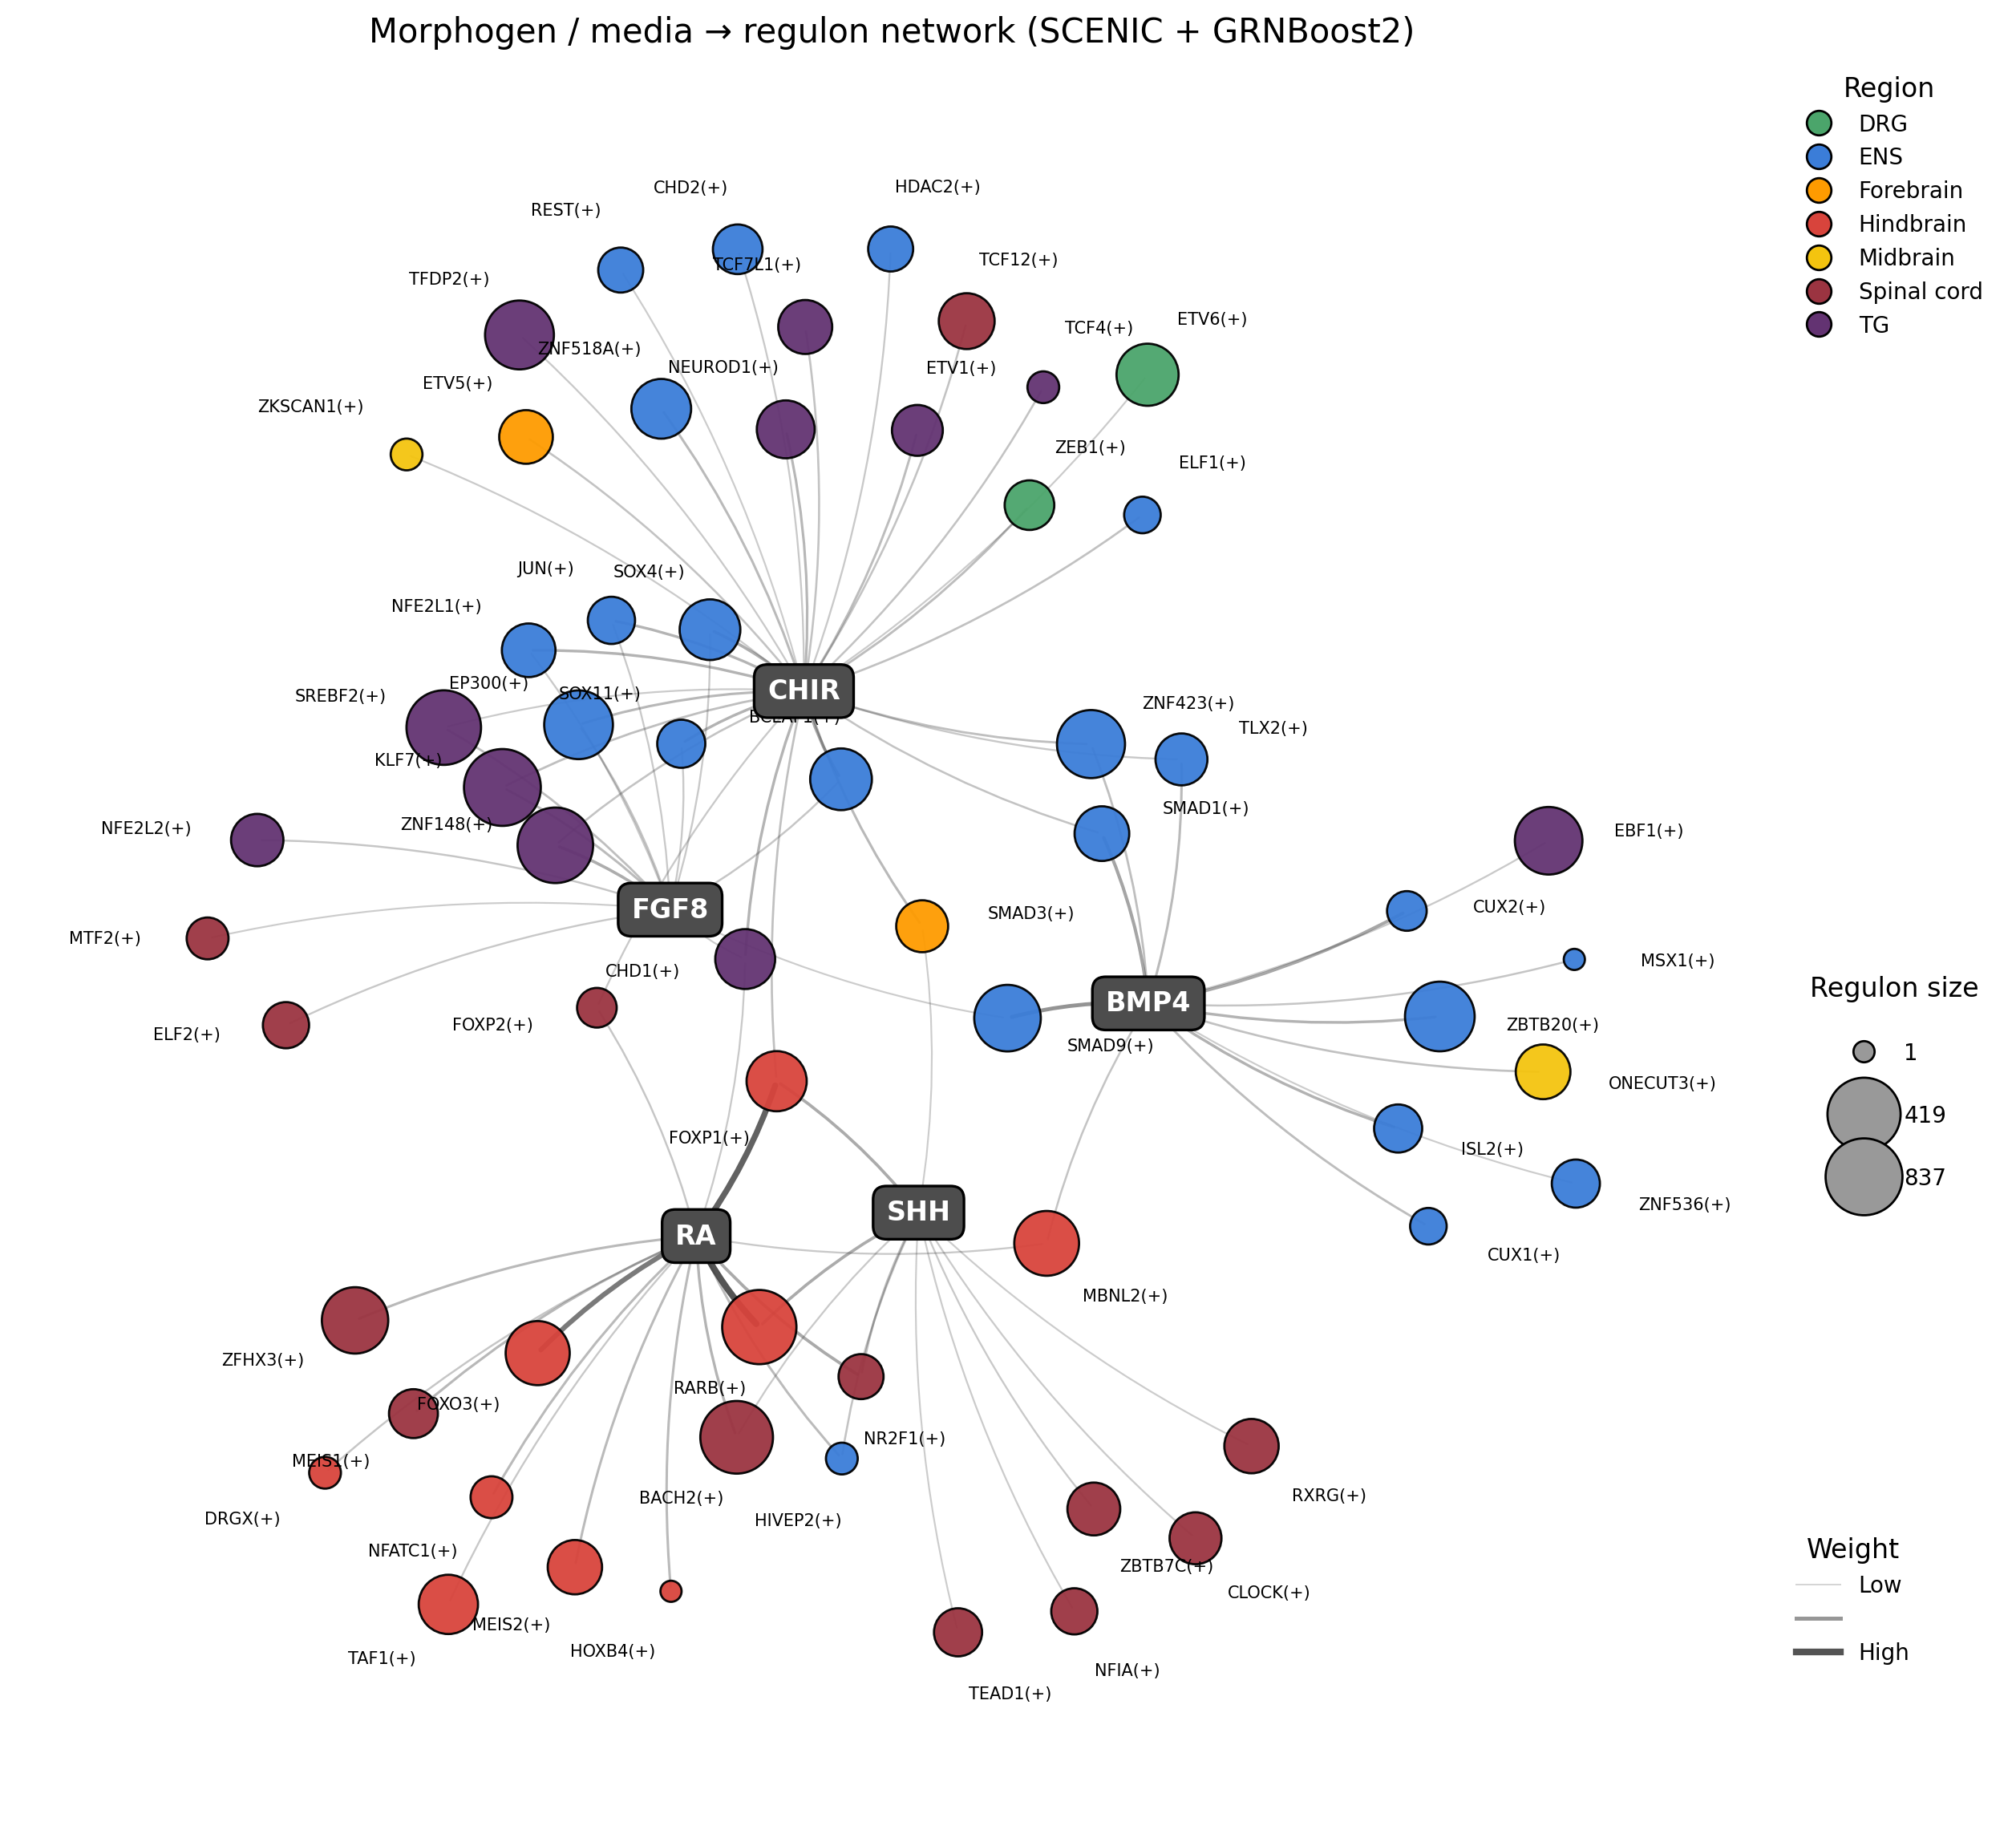

In [21]:
adata = load_adata()
if not (USE_PRECOMPUTED and os.path.exists(os.path.join(OUTDIR, "consensus_regulons.p"))):
    step_scenic(adata)   # skipped when the consensus regulons are already available
step_consensus()
step_aucell(adata)
step_morphogens(adata)
step_postprocess()
png = step_figure(adata)

from IPython.display import Image, display
display(Image(filename=png))

In [22]:
adata.obs = pd.concat([adata.obs, auc_matrix], axis=1)

NameError: name 'auc_matrix' is not defined

In [ ]:
%matplotlib inline
sc.pl.umap(adata, color=["TCF12(+)"], show=True)

In [19]:
# Time started 21:36